## Hidden Markov Model For Process Behavior Estimation
### CPU Intensive GP Workloads
#### Braden Everson

Process: We will split the difference percentages of CPU usage as discrete "states." Instead of a continuous function estimation like with ARIMA, the HMM will predict the most likely state the process will transition into during its next runtime given some history

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

In [2]:
series = pd.read_csv("../gp-workloads/time_slices/cpu_intensive_2/cpu_intensive_2_waitrun_5000us.csv")
# series = pd.read_csv("../gp-workloads/time_slices/cpu_intensive_7/cpu_intensive_7_waitrun_5000us.csv")
# series = pd.read_csv("../gp-workloads/time_slices/cpu_intensive_12/cpu_intensive_12_waitrun_500us.csv")

In [3]:
series

,bin_index,start_time_us,end_time_us,waiting_time_us,running_time_us,waiting_pct,running_pct
0,0,0,5000,300,4700,6.000000,94.000000
1,1,5000,10000,202,4798,4.040000,95.960000
2,2,10000,15000,127,4873,2.540000,97.460000
3,3,15000,20000,116,4884,2.320000,97.680000
4,4,20000,25000,124,4876,2.480000,97.520000
...,...,...,...,...,...,...,...
211,211,1055000,1060000,312,4688,6.240000,93.760000
212,212,1060000,1065000,373,4627,7.460000,92.540000
213,213,1065000,1070000,290,4710,5.800000,94.200000
214,214,1070000,1075000,295,4705,5.900000,94.100000


In [4]:
X = series[["running_pct"]].values

initial_means = np.array([[95.0], [50.0], [5.0]])

model = hmm.GaussianHMM(n_components=3, covariance_type="diag", init_params="stc")
model.means_ = initial_means

model.fit(X)

GaussianHMM(init_params='stc', n_components=3)

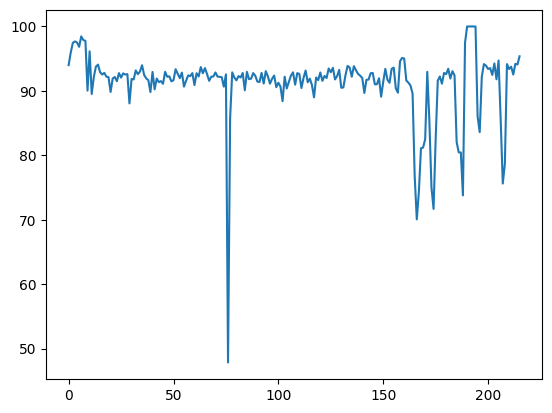

In [5]:
plt.plot(X)

In [6]:
pred = model.predict(X)

In [7]:
model.means_

array([[92.21208109],
       [87.09696073],
       [48.04709104]])

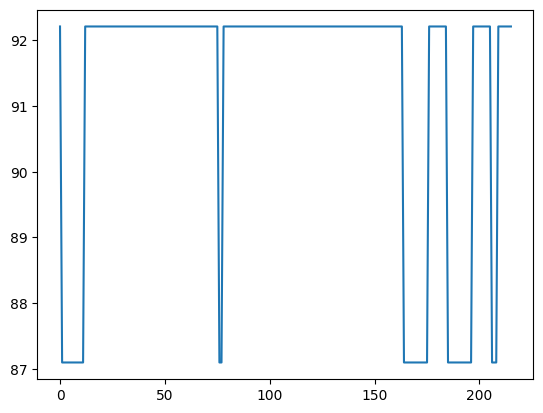

In [8]:
plt.plot(model.means_[pred])

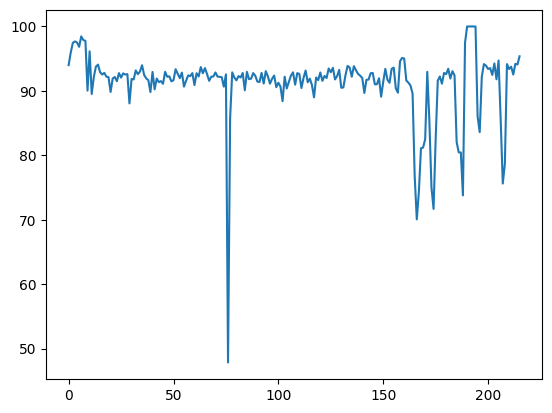

In [9]:
plt.plot(X)

Conclusion: I don't think Hidden Markov Models will be helpful for this use case.